# Georg-August-Universität Göttingen - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Georg-August-Universität Göttingen' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              142 -- 'Georg-August-Universität Göttingen'
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Georg-August-Universität Göttingen,"Department of Neonatology, Clinic for Paediatr...",https://openalex.org/W4206936848
1,not assigned,Georg-August-Universität Göttingen,"Institute of Pharmacology and Toxicology, Univ...",https://openalex.org/W4223433457
2,not assigned,Georg-August-Universität Göttingen,"Department of Neurology, University Medical Ce...",https://openalex.org/W4223433457
3,not assigned,Georg-August-Universität Göttingen,"Department of Neurology, University Medical Ce...",https://openalex.org/W4223512969
4,not assigned,Georg-August-Universität Göttingen,Department of Forest Genetics and Forest Tree ...,https://openalex.org/W4306385394


In [54]:
MAPPING_DICT = {
    'Bernstein Zentrum für Computational Neuroscience Göttingen': ['computational neuroscience', 'bernstein zentrum'], # selbst ergänzt
    'Campus Institut für Dynamik biologischer Netzwerke (CIDBN)': ['biological networks', 'biologischer netzwerke'],
    'Campus-Institut Data Science (CIDAS)': ['cidas', 'campus(-|‐|\s)inst(.|itut(e)?) data science'],
    'Centre for Modern Indian Studies (CeMIS)': ['cent(er|re) for modern indian studies'],
    'Center for Integrated Breeding Research (CiBreed)': ['int\w* breeding', 'breeding research'], # selbst ergänzt
    'Courant Forschungszentrum Armut, Ungleichheit und Wachstum in Entwicklungsländern': ['poverty equity'],
    'Courant Forschungszentrum Bildung und Religion': ['bildung und religion'],
    'Courant Forschungszentrum Evolution des Sozialverhaltens': ['evolution des sozialverhaltens', 'evolution of social behaviour'],
    'Courant Forschungszentrum Nanospektroskopie und Röntgenbildgebung': ['nanospektroskopie', 'nano-spectroscopy'],
    'Courant Forschungszentrum Geobiologie': ['courant forschungszentrum geobiologie', 'courant research centre geobiology'],
    'Courant-Forschungszentrum Textstrukturen': ['textstrukturen', 'text structures'],
    'DFG Forschungszentrum für Molekularphysiologie des Gehirns': ['molekularphysiologie', 'molecular physiology'],
    'Erasmus Mundus Programme Euroculture - Society, politics and culture in a global context': ['erasmus mundus'],
    'Fakultät für Agrarwissenschaften': ['landwirtschaftlich', 'agricultural(?!(\ssoil|\suniversity|\slaw))', 'veterinary', 'crop (science|plant|production|protection)', 
                                         'mycotoxin', 'soil hydrology', 'nutzpflanzen', 'faculty of agriculture', 'agrosystems modelling',
                                         'agro(ecology|biodiversity|nomy)', 'biogeochemistry', 'plant (pathology|breeding|nutrition|products)', 
                                         'animal (medicine|hygiene|breeding|science|plant)', 'husbandry', 'agrarökonomie', 'grassland', 
                                         'tierärztliches institut', 'agrarökosysteme', 'breeding informatics', 'functional breeding'
                                        ],
    'Fakultät für Biologie und Psychologie': ['biolog(ie|y) (and|und|&) psycholog(ie|y)', 'blumenbach', 'evolution of plants', 'georg-elias', 'conservation biology',
                                              '(department|institute) of psychology', '(animal|human|behavio(u)?ral) ecology', 'climate dynamics', 'applied bioinformatics',
                                              'cent(er|re) (of|for) molecular biosciences', 'von(-|‐|\s)haller', 'plant cell biology', 
                                              'zoolog(ie|y) (und|and) anthropolog(ie|y)', 'zelluläre neurobiologie', 'biology education',
                                              '(educational|developmental|experimental|social|clinical) psychology', 'plant ecology', 
                                              'mi(k|c)robiolog(ie|y) (und|and|&amp;) geneti(k|cs)', 'behavioural biology', 'plant biochemistry',
                                              '(so(z|c)io|neuro)biolog(ie|y)', 'psychologie und psychotherapie', 'molecular structural biology', 
                                              'psychology of language', 'phycology', '(general|applied) microbiology', 'developmental biology',
                                              'vegetation', '(abteilung|animal) evolution', '(?<!integrative\s)(?<!auditory\s)genomic', 
                                              ' social and communication', 'institute for microbiology', 'molecular biosciences', 'epsag',
                                              'evolutionary developmental', 'zentrum für molekulare biowissenschaften', 'department of bioinformatics'
                                             ],
    'Fakultät für Chemie': ['(?<!bio)(physi(kalische|cal)|(an|in)organi(sche|c)) chemi(e|st(r)?y)', 'bi(o)?mole(k|c)ular', '(faculty|department) of chemistry', 
                            'w(ö|oe)hler', 'organic chemistry', 'fakultät für chemie', 'fachdidaktik chemie'
                           ],
    'Fakultät für Forstwissenschaften und Waldökologie': ['forest', 'wood', 'ecosystem modelling',
                                                          'radio(‐|-)?isotopes', '(soil|wildlife) science', 'stable isotope', 'bioclimatology',
                                                          'wildlife', 'forstwissenschaften', 'conservation policy', 'forstgenetik', 'silviculture',
                                                          'waldökologie'
                                                         ],
    'Fakultät für Geowissenschaften und Geographie': ['geo(dynamics|science|graphical)', 'mineralog(ie|y)', 'geowissenschaftliches (zentrum|museum)', 
                                                      '(physical|human|kristallo)(\s)?(geo)?graph(ie|y)', 'intitute of geography',
                                                      'sedimentolog(ie|y)', 'cartography', '(angewandte|applied|isotope(n)?)(\s)?geolog(ie|y)', 'geoscientific',
                                                      '(department|institute) of geo(biology|graphy)', 'abt(.|eilung) geochemie', 'geographisches',
                                                      'center for earth sciences', 'strukturgeologie', 'faculty of geology'
                                                     ],
    'Fakultät für Mathematik und Informatik': ['computer science', 'mathemati(k|cs|sch)', 'stochastic', 'bernstein‐institute', 'institut(e)? (für|of) informati(k|cs)',
                                               'maschinelles lernen', 'computer security', 'math(ematical)? institut', 'centre for digital humanities',
                                               'scientific information analytics group', 'scientific information analytics'
                                              ],
    'Fakultät für Physik': ['geophysik', 'complex systems', 'friedrich-hund', 'x(‐|-)ray physics', 'physics—biophysics', 
                            '(institute|fa(k|c)ult(ät|y)|department) (der|für|of) physi(k|cs)', 'didaktik der physik',
                            'phys(.|ikalisches|ical|ics) institut', 'theoreti(sche|cal) physi(k|cs)', 'material(s)?(\s)?physi(k|cs)', '(astro|r(ö|o)ntgen)physi(k|cs)',
                            'physics education'
                           ],
    #'Forum für interdisziplinäre Religionsforschung (FiReF)': [],
    'Gesellschaft für wissenschaftliche Datenverarbeitung mbH Göttingen': ['(?<!@)(?<!mail.)gwdg', 'escience', 
                                                                           'gesellschaft (für|f&#x00FC;r) wissenschaftliche(,)? datenverarbeitung'
                                                                          ],
    #'Graduiertenschule für Geisteswissenschaften Göttingen (GSGG)': [],
    'Göttinger Graduiertenzentrum für Neurowissenschaften': ['center nanoscale microscopy', 'molecular enzymology'], 
    #'Göttinger Graduiertenzentrum für Neurowissenschaften, Biophysik und Molekulare Biowissenschaften (GGNB)'
    'Informationsverbund Dermatologischer Kliniken (IVDK)': ['informationsverbund dermatologischer kliniken'],
    #'Interdisziplinäres Zentrum für Nachhaltige Entwicklung': [],
    'Juristische Fakultät': ['(rechts|kriminal)wissenschaften', 
                             '(bio|medizin|(jugend)?straf|landwirtschafts|arbeits|europa|familien|staatskirchen|verwaltungs|gesellschafts)recht', 
                             'faculty of law', '(labour|agricultural|roman|criminal|procedural|european|economic) law', 'juristische fakultät', 'grundlagen des rechts'
                            ],
    'Lichtenberg-Kolleg': ['lichtenberg'],
    'Niedersächsische Staats- und Universitätsbibliothek': ['bibliothek', 'library', 'papendiek 14', 'sub göttingen'],
    'Philosophische Fakultät': ['arch(a)?eology', '(früh|neuere)(\s)?geschichte', 'english', '(?<!social\s)(?<!sozial)philo(soph(ie|y)|log(ie|y))', 
                                'sprachwissenschaft', '(iranian|(east )?asian|romance|persianate|american|islamic) studies', 
                                'protohistory', 'romance languages', 'musicol(ogy)?', 'anglophone literature',
                                'cultural anthropology', 'faculty of humanities', '(early|regional|modern) history', 
                                '(althistorisches|skandinavisches|ostasiatisches|philosophisches) seminar',
                                'kulturanthropologie', 'romance department', 'ägyptologie', 'department of history'
                               ],
    #'Sonderforschungsbereich 1136': [],
    'Sozialwissenschaftliche Fakultät': ['(institut(e)?|faculty) (für|of) (so(z|c)i|political|methoden)', 'democracy (research|studies)',
                                         '(sport(s)?|political|educational) science', '(politik|sport|erziehungs)wissenschaft', 'erziehungswissensch',
                                         'sozialwissenschaftliche fakultät', 'department of social sciences', 'social science(s)? faculty'
                                        ],
    'Theologische Fakultät': ['theologische fakultät', 'theolog(ie|y)'],
    'Universitätsmedizin Göttingen (UMG)': ['univ(ersi(t)?((ä|a|ae)ts|y)|.)?(\s|\sof\s)?(med|hosp|klinik)', 'gyn(äk|ec)olog(ie|y)', 'dentistry', 'cardiovascular',
                                            'medical (university )?(cent(re|er)|school|clinic|science)?', 'neuroimmunology', 'cardiology', 'psychosomatic',
                                            'h((a)?e|ä)matolog(ie|y)', 'radiolog(ie|y)', 'neurolog(ie|y)', 'medical (bio)?informatics', 'pneumology', '(augen|kinder|frauen)klinik',
                                            'pharmacology', 'an((a)?e|ä)sthesiolog(ie|y)', 'bioimaging', 'psychiatry', 'psychoneuroscience', 'dental', 'anatomy',
                                            'heart cent(er|re)', '(palliativ|intensiv)medizin', 'cellular biophysics', 'medizinische (statistik|informatik)', 'nephrolog(ie|y)',
                                            'infektiologie', '(trauma|neuro|thoracic|neck|vascular|reconstructive)(\s)?surgery', 'epidemiology', 'medizin und psychotherapie',
                                            'otorhinolaryngology', 'maxillofacial', 'jugendpsychiatrie', 'molecular cell', 'gastroenterolog(ie|y)',
                                            'otolaryngology', '889', '1690', '1286', '(department|faculty) of medicine', 'dermatolog(ie|y)', 'infectious diseases',
                                            '(nuclear|internal) medicine', 'orthop(a)?edics', '(gesichts|unfall|kinder|thorax)chirurgie', 'hno(\s|-)((uni)?klinik|göttingen)',
                                            'cellular biochemistry', 'forensi(sch|c)', 'geriatri(e|cs)', 'frauenheilkunde', "children's hospital",
                                            'klinik für psychiatrie', 'neuropathology', 'p(a)?ed(r)?iat(r)?ic', 'clinical (psychology|chemistry)', 'ophthalmol',
                                            'cardiovasc', 'molecular oncology', 'virology', 'sensory physiology', 'general (practice|surgery)',
                                            'human(\s)?geneti(k|cs)', 'rheumatolog(ie|y)', 'institute of pathology', 'radiotherapy', 'neurophysiolog(ie|y)',
                                            'medizinische fakultät', '(umg|uniklinik) göttingen', 'molekulare psychiatrie', 'synaptic physiology',
                                            'integrative genomics', 'developmental biochemistry', 'comprehensive cancer center', 'geschichte der medizin',
                                            'biostructural imaging'
                                           ],
    'Wirtschaftswissenschaftliche Fakultät': ['econometrics', 'innovation', 'department (of|for) economics', 'economic (sciences|policy)', 'business and economics',
                                              'business (education|administration)', '(?<!cellular\s)logistics', '(professur|chair) (für|of) (marketing|statisti(k|cs)|financ(e|ial))',
                                              'information(s|\s)(management|systems)', 'anwendungssysteme', 'application systems', 'sozialgeschichte',
                                              '(development|public) economics', 'rechnungslegung', 'wirtschaftspädagogik', 'management and control', 
                                              'information security', 'volkswirtschaftslehre', 'wirtschaftswissenschaftliche fakultät', 'fakultät für wirtschaftswissenschaften',
                                              'economics department'
                                             ],
    #'Zentrale Kustodie': [],
    #'Zentrum für Antike und Orient': [],
    'Zentrum für Biodiversität und Nachhaltige Landnutzung': ['cent(er|re) (for|of) (biodivers(i|o)ty|sustainable)', 'biogeograph(ie|y)'], 
    'Zentrum für empirische Unterrichts- und Schulforschung (ZeUS)': ['schulforschung', 'school research'],
    'Zentrum für Globale Migrationsstudien (CeMig)': ['globale migrationsstudien', 'global migration studies'],
    'Zentrum für Statistik': ['zentrum für statistik'],
    'ZESS - Zentrale Einrichtung für Sprachen und Schlüsselqualifikationen': ['schl(ü|ue)sselqualifikationen'],
    ## Weitere Zentren
    #'International Center of Advanced Studies of Energy Conversion': ['advanced studies of energy conversion', 'advanced energy studies'], # selbst ergänzt
    ## An-Institute
    #'Volkswirtschaftliches Institut für Mittelstand und Handwerk an der Universität Göttingen e.V.': ['small business economics', 'mittelstand und handwerk'],
    #'Leibniz-WissenschaftsCampus Primatenkognition': ['primate (cognition|research)'],
}

In [55]:
with open('./mapping_tables_fak/gau.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [8]:
df_with_inst = oal.copy()

In [9]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [10]:
df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [11]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Neonatology, Clinic for Paediatr...",https://openalex.org/W4206936848
1,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Institute of Pharmacology and Toxicology, Univ...",https://openalex.org/W4223433457
2,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Neurology, University Medical Ce...",https://openalex.org/W4223433457
3,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Neurology, University Medical Ce...",https://openalex.org/W4223512969
4,Fakultät für Forstwissenschaften und Waldökologie,Georg-August-Universität Göttingen,Department of Forest Genetics and Forest Tree ...,https://openalex.org/W4306385394
...,...,...,...,...
43427,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Institute of Neuropathology, Universitätsmediz...",https://openalex.org/W3010847380
43428,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"MR-Research in Neurology and Psychiatry, Georg...",https://openalex.org/W3112679776
43429,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Psychiatry and Psychotherapy, Un...",https://openalex.org/W3112679776
43430,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Hematology and Oncology, Univers...",https://openalex.org/W3096630378


In [12]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[20:40]

array(['Leibniz University Hannover and University of Göttingen, 37075 Göttingen, Germany schupp@glad.uni-hannover.de',
       'University of Göttingen, 37073 Göttingen, Germany friederike.lenel@uni-goettingen.de',
       'Georg-August-Universität Göttingen',
       'Deutsch Primate Center, University of Goettingen, Goettingen 37707, Germany',
       'Georg-August-Universität',
       'Giftinformationszentrum-Nord der Länder Bremen, Hamburg, Niedersachsen und Schleswig-Holstein, Georg-August-Universität Göttingen, Robert-Koch-Str.\xa040, 37075, Göttingen, Deutschland',
       'Collaborative Research Center SFB1190 "Compartmental Gates and Contact Sites in Cells", University of Göttingen, 37073, Göttingen, Germany',
       ') Georg-August-Universität Göttingen, Germany',
       'Food Quality and Design Group, Department of Agrotechnology and Food Sciences, Wageningen University & Research, P.O. Box 17, Bornse Weilanden 9, 6708 WG, Wageningen, the Netherlands; Isi GmbH, Ascherberg 2, 371

In [13]:
# check affiliated hosp
df_with_inst[df_with_inst.raw_affiliation_string.str.contains('affiliated')]

,fak_name,parent_name,raw_affiliation_string,openalex_id
2255,None,Georg-August-Universität Göttingen,"Independent scholar, Formerly affiliated with ...",https://openalex.org/W4405953300


In [14]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Bernstein Zentrum für Computational Neuroscien...,126
1,Campus Institut für Dynamik biologischer Netzw...,86
2,Campus-Institut Data Science (CIDAS),392
3,Center for Integrated Breeding Research (CiBreed),345
4,Centre for Modern Indian Studies (CeMIS),271
5,Courant Forschungszentrum Bildung und Religion,1
6,Courant Forschungszentrum Evolution des Sozial...,2
7,Courant-Forschungszentrum Textstrukturen,3
8,DFG Forschungszentrum für Molekularphysiologie...,183
9,Fakultät für Agrarwissenschaften,3304


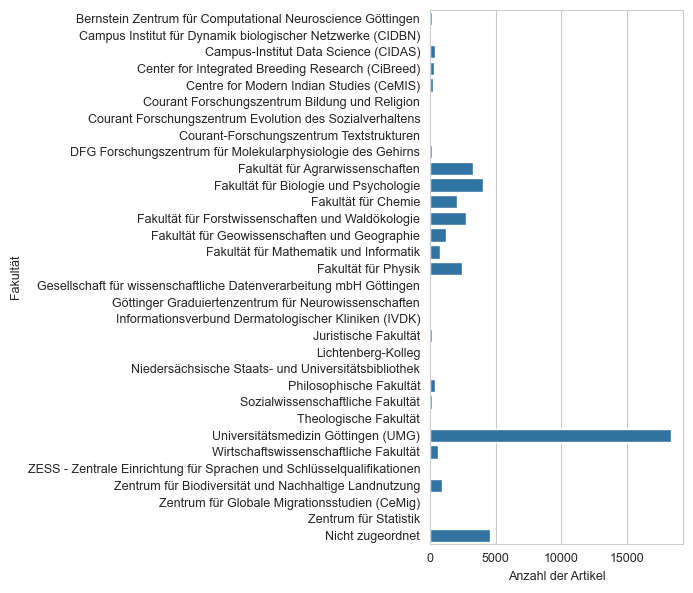

In [15]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [16]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.894478725363787

In [73]:
MAPPING_DICT_DEPT = {
    'Fakultät für Agrarwissenschaften': {
        #'Außenstelle Vechta': [],
        'Department für Agrarökonomie und Rurale Entwicklung': ['(agricultural|rural) economics', 'agrarökonomie', 'rural development', 'agricultural products',
                                                                'social(-|‐|\s)ecological interactions'
                                                               ],
        'Department für Nutzpflanzenwissenschaften': ['crop (science|plant|production)', 'agroecosystems', 'biogeochemi(e|stry)', 'agro(ecology|biodiversity)', 'entomology', 
                                                      'phytopathology', 'plant breeding', 'pathology', 'grassland', 'agronomy', 'plant products', 
                                                      'sensory', 'crop protection', 'tropical plant', 'plant nutrition', 'nutzpflanzenwissenschaften',
                                                      'soil hydrology'
                                                     ],
        'Department Nutztierwissenschaften': ['animal (science|husbandry|medicine|hygiene|breeding)', 'veterinary medicine', 'nutztiere', 'tierärztliches',
                                              'breeding informatics'
                                             ]
        #'Institut für angewandte Pflanzenernährung (IAPN)': []
    },
    'Fakultät für Biologie und Psychologie': {
        'Albrecht-von-Haller-Institut für Pflanzenwissenschaften': ['von(-|‐|\s)haller', 'bio(diversit(ät|y)|chemistry)', 'climate dynamics', 'plant ecology',
                                                                    'phycology', 'vegetation', 'molecular enzymology', 'plant cell'
                                                                   ],
        'Georg-Elias-Müller-Institut für Psychologie': ['georg(-|‐|\s)elias', '(department|institute) of psychology', 
                                                        '(developmental|educational|experimental|communication) psychology', 
                                                        'psychotherap(ie|y)', 'psychology of language'],
        'Institut für Mikrobiologie und Genetik': ['microbiology', 'molecular biosciences', 'microscopy', 'molekulare genetik', 'mikrobiologie',
                                                   'biowissenschaften', 'bioinformatics', 'structural biology'
                                                  ],
        'Johann-Friedrich-Blumenbach Institut für Zoologie und Anthropologie': ['blu(e)?menbach', 'sociobiology', 'anthropology', 
                                                                                '(developmental|conservation|multiscale) (biology|genetics)', 'abteilung evolution',
                                                                                'behavioral', 'animal ecology', 'neurobiolog(ie|y)'
                                                                               ]
    },
    'Fakultät für Chemie': {
        'Institut für Anorganische Chemie': ['anorganische chemie', 'inorganic chemist(r)?y', 'chemistry education'],
        'Institut für Organische und Biomolekulare Chemie': ['(?<!an)organische chemie', '(?<!in)organic chemist(r)?y', 'biomolekular(e)? chemie',
                                                             'biomolecular chemistry'
                                                            ],
        'Institut für Physikalische Chemie': ['physikalische chemie', 'physical chemistry'],
        'Friedrich-Wöhler-Forschungsinstitut für Nachhaltige Chemie': ['w(ö|oe)hler(-|‐|\s)(research|(forschungs)?institut)']
    },
    'Fakultät für Forstwissenschaften und Waldökologie': {
        'Juniorprofessur für Holztechnologie und Holzchemie': ['holzchemie', 'wood chemistry'],
        'Professur für Räumliche Strukturen und Digitalisierung von Wäldern': ['räumliche strukturen', 'spatial structures'],
        'Abteilung Landschaftshydrologie': ['hydrolog(ie|y)'],
        'Burckhardt-Institut': ['wood (biology|technology)', 'silviculture', 'nature conservation', 'remote sensing', 'conservation policy',
                                'naturschutzpolitik', 'nature forest conservation', 'forest work'
                               ],
        'Büsgen-Institut': ['(soil|wildlife) (science|biology)', 'tree (breeding|physiology)', 
                            'forstgenetik', 'ecosystem modelling',
                            'bioclimatology', 'büsgen-institute', 'radio(‐|-)?isotopes', 
                            'biometrics', 'wood biotechnology',
                           ],
        'Kompetenzzentrum Stabile Isotope': ['isotope research', 'stabile isotope'],
        #'Stiftungsprofessur Forstliche Phytopathobiome': [],
    },
    'Fakultät für Geowissenschaften und Geographie': {
        'Geographisches Institut': ['(physical|human) geography', 'cartography', 'geographisches institut', 'institute of geography'],
        'Geowissenschaftliches Zentrum (GZG)': ['(applied|structural) geo(logy|science)', 'geochemi(e|stry)', 'geo(science(s)?|scientific) cent(er|re)', 
                                                'geowissenschaftliches zentrum', 'centre of geosciences', 'isotope geology', 'isotopengeologie',
                                                'computational', 'angewandte geologie', 'sediment', 'mineralog(ie|y)', 'geobiology'
                                               ]
    },
    'Fakultät für Mathematik und Informatik': {
        #'CRC - Courant Forschungszentrum "Strukturen höherer Ordnung"': [],
        'Institut für Informatik (IfI)': ['institut für informatik', '(institut(e|ion)|department) (of|for) (computer science|informati(k|c))', 'computer security',
                                          'maschinelles lernen', 'computer science department'
                                         ],
        'Institut für Mathematische Stochastik (IMS)': ['stochasti(k|c)'],
        'Institut für Numerische und Angewandte Mathematik (NAM)': ['angewandte mathematik', 'appl(.|ied) mathematics'],
        'Mathematisches Institut (MI)': ['mathematisches institut', 'mathematic(al|s) institute', 'institut für mathematik', 'math institut'],
        #'Sino-German Institute of Social Computing': [],
        #'Zentrum für Angewandte Informatik': [],
    },
    'Fakultät für Physik': {
        'Arbeitsgruppe Didaktik der Physik': ['physics education', 'dida(k|c)ti(k|c)'],
        'I. Physikalisches Institut': ['(?<!i)i\.', '(first|1st|(?<!i)i)(\sphysical)? institute', '(erstes|(?<!i)i)(\sphysikalisches)? institut'],
        'II. Physikalisches Institut': ['(?<!i)ii\.', '(second|2nd|(?<!i)ii)(\sphysical)? institute', '(zweites|(?<!i)ii)(\sphysikalisches)? institut'],
        'III. Physikalisches Institut': ['(?<!i)iii\.', '(t(\s)?hird|3rd|(?<!i)iii)(\sphysical)? institute', '(drittes|(?<!i)iii)(\sphysikalisches)? institut'],
        'IV. Physikalisches Institut': ['iv\.', '(fourth|4th|iv)(\sphysical)? institute', '(viertes|iv)(\sphysikalisches)? institut', 'nanostructures'],
        'Institut für Astrophysik und Geophysik': ['astrophysi(k|c)', 'geophysi(k|c)'],
        'Institut für Dynamik komplexer Systeme': ['complex (systems|fluids)', 'komplexer systeme'],
        'Institut für Materialphysik': ['material(s)? physics', 'materia(l)?physik'],
        'Institut für Röntgenphysik': ['x(-|‐)ray', 'röntgenphysik'],
        'Institut für Theoretische Physik': ['theoreti(sche|cal)'],
    },
    'Juristische Fakultät': {
        'Institut für Arbeitsrecht': ['arbeitsrecht', 'labour law'],
        'Institut für Grundlagen des Rechts': ['social philosophy', 'sozialphilosophie'],
        'Institut für Kriminalwissenschaften': ['kriminalwissenschaften', 'kriminologie', 'landwirtschaftsrecht', 'strafrechtliches medizin', 
                                                '(criminal|agricultural) law'],
        'Institut für Privat- und Prozessrecht': ['medizinrecht', 'familienrecht'],
        'Institut für Völkerrecht und Europarecht': ['europarecht'],
        #'Institut für Wirtschaftsrecht': [],
        'Institut für Öffentliches Recht': ['öffentliches recht']
    },
    'Philosophische Fakultät': {
        'Althistorisches Seminar': ['althistorisches seminar'],
        'Archäologisches Institut und Sammlung der Gipsabgüsse': ['historic(al)? arch(a)?eology'],
        #'Christliche Archäologie und Byzantinische Kunstgeschichte': [],
        #'Diplomatischer Apparat': [],
        #'Finnisch-Ugrisches Seminar': [],
        #'Institut für Digital Humanities': [],
        'Institut für Historische Landesforschung': ['regional history'],
        'Institut für Kulturanthropologie/Europäische Ethnologie': ['anthropology'],
        #'Institut für Religionswissenschaft': [],
        #'Kunstgeschichtliches Seminar und Kunstsammlung': [],
        #'Moritz-Stern-Institut': [],
        'Musikwissenschaftliches Seminar': ['musicology'],
        'Ostasiatisches Seminar': ['asian studies'],
        'Philosophisches Seminar': ['philosophisches seminar', 'institut(e)? of philosophy'],
        #'Seminar für Altorientalistik': [],
        'Seminar für Arabistik / Islamwissenschaft': ['islamic studies'],
        'Seminar für Deutsche Philologie': ['german philology', 'deutsche philologie'],
        'Seminar für Englische Philologie': ['english (philology|linguistics|studies)', '(englische|klassische|classical) philolog(ie|y)', 'english department', 
                                             'iranian studies', 'department of english'
                                            ],
        'Seminar für Mittlere und Neuere Geschichte': ['(neuere|frühere) geschichte'],
        'Seminar für Romanische Philologie': ['romance (studies|languages)', 'romanische philologie'],
        'Seminar für Slavische Philologie': ['slavi(sche|c)) philolog(ie|y)'],
        #'Seminar für Turkologie und Zentralasienkunde': [],
        'Seminar für Ur- und Frühgeschichte': ['frühgeschichte', 'early history'],
        'Seminar für Ägyptologie und Koptologie': ['ägyptologie'],
        'Skandinavisches Seminar': ['skandinavisches seminar'],
        'Sprachwissenschaftliches Seminar': ['sprachwissenschaft'],
        'Zentrum für Mittelalter- und Frühneuzeitforschung': ['modern history', 'protohistory', 'frühneuzeitforschung'],
        #'Sonderforschungsbereich 1136': [],
    },
    'Sozialwissenschaftliche Fakultät': {
        'Institut für Demokratieforschung': ['demokratieforschung', 'democracy (studies|research)'],
        'Institut für Diversitätsforschung': ['diversity research'],
        'Institut für Erziehungswissenschaft': ['erziehungswissenschaft', 'educational science', 'center of methods'],
        'Institut für Politikwissenschaft': ['politikwissenschaft', 'political science'],
        'Institut für Soziologie': ['institut für soziologie', 'institute of sociology'],
        'Institut für Sportwissenschaften': ['sportwissenschaften', 'sport(s)? science'],
        'Koordinationsstelle Geschlechterforschung': ['gender studies']
    },
    'Theologische Fakultät': {
        'Institut für Spezialforschungen': ['lehrstuhl für kirchengeschichte', 'church history'],
        'Vereinigte Theologische Seminare': ['religionspädagogik', 'alttestamentliches seminar', 
                                             'systematischen theologie', 'religious education'],
    },
    'Universitätsmedizin Göttingen (UMG)': {
        'Abteilung Experimentelle Neurodegeneration': ['experimentelle neurodegeneration', 'experimental neurodegeneration'],
        'Abteilung für Geriatrie': ['geriatri(e|cs)'],
        'Abteilung Nuklearmedizin': ['nuclear medicine', 'nuklearmedizin'],
        'Abteilung Rechtsmedizin': ['rechtsmedizin', 'legal department'],
        'Abteilung Molekulare Onkologie': ['molecular oncology'], # selbst ergänzt
        'Center for Biostructural Imaging of Neurodegeneration (BIN)': ['biostructural', 'imaging of neurodegeneration'],
        #'Deutsches Zentrum für Kinder und Jugendgesundheit': [],
        'European Neuroscience Institute (ENI-G)': ['european neuroscience'],
        'Exzellenzcluster Multiscale Bioimaging': ['multiscale'],
        'Herzzentrum Göttingen': ['cardiology (and|&) pneumolo(g)?y', 'heart(\sresearch)? center', 'clinic for cardiology', 'herzzentrum', 
                                  'kardiologie und pneumologie'
                                 ],
        'Institut für Allgemeinmedizin': ['general practice', 'allgemeinmedizin'],
        'Institut für Arbeits-, Sozial- und Umweltmedizin': ['umweltmedizin'],
        'Institut für Auditorische Neurowissenschaften': ['auditory neuroscience', 'auditorische neurowissenschaften'],
        'Institut für Bioinformatik': ['bioinformatik'],
        'Institut für Diagnostische und Interventionelle Neuroradiologie': ['interventionelle radiologie', 'neuroradiolog(ie|y)'],
        'Institut für Ethik und Geschichte der Medizin': ['medical ethics', 'ethik und geschichte'],
        'Institut für Genetische Epidemiologie': ['epidemiolog(ie|y)'],
        'Institut für Humangenetik': ['human(\s)?genetics', 'humangenetik'],
        'Institut für Klinische Chemie': ['clinical chemistry', 'klinische chemie'],
        'Institut für Klinische Pharmakologie': ['clinical pharmacology'],
        'Institut für Klinische und Interventionelle Radiologie': ['interventional radiology', 'cardiac imaging'],
        'Institut für Kognitive Neurologie': ['cognitive neurology'],
        'Institut für Medizinische Bioinformatik': ['medical bioinformatics'],
        'Institut für Medizinische Informatik': ['medical informatics', 'medizinische informatik', 'medizininformatik'],
        'Institut für Medizinische Mikrobiologie': ['virolog(ie|y)', 'medical microbiology'],
        'Institut für Medizinische Psychologie und Medizinische Soziologie': ['medical sociology'],
        'Institut für Medizinische Statistik': ['medizinische statistik', 'medical statistics'],
        'Institut für Neuroimmunologie und Multiple-Sklerose-Forschung': ['neuroimmunologie', 'multiple sclerosis', 'sklerose'],
        'Institut für Neuropathologie': ['neuropatholog(ie|y)'],
        'Institut für Neurorehabilitationssysteme': ['neurorehabilitationssysteme'],
        'Institut für Pathologie': ['(institute|department) (for|of) pathology', 'institut für pathologie'],
        'Institut für Pharmakologie und Toxikologie': ['toxi(k|c)olog(ie|y)'],
        'Institut für Zelluläre und Molekulare Immunologie': ['molekulare immunologie', 'molecular immunology'],
        'Interdisziplinäre Notaufnahme (INA)': ['notaufnahme', 'emergency department'],
        'Klinik für Allgemein-, Viszeral- und Kinderchirurgie': ['kinderchirurgie', 'visceral', 'department of surgery', 'klinik für allgemein-'],
        'Klinik für Anästhesiologie': ['an(ä|e|ae)sthesiolog(ie|y)'],
        'Klinik für Augenheilkunde': ['augen(klinik|heilkunde)', '(clinic|department) of ophthalmology', 'eye center'],
        'Klinik für Dermatologie, Venerologie und Allergologie': ['dermatolog(ie|y)'],
        'Klinik für Gastroenterologie und gastrointestinale Onkologie': ['gast(e)?roenterolog(ie|y)'],
        'Klinik für Geburtshilfe und Gynäkologie': ['gynecology', 'gynäkologie'],
        'Klinik für Hals-Nasen-Ohrenheilkunde': ['hno(\s|-)(klinik|göttingen|heilkunde)', 'hals(-|-)nasen(-|-)ohren(klinik|heilkunde)', 
                                                 'otorhinolaryngology', 'otolaryngology', 'ohrenheilkunde'
                                                ],
        'Klinik für Hämatologie und Medizinische Onkologie': ['klinik für hämatologie', '(department|clinic(s)?) of hematology', 
                                                              'medical (h(a)?ematology|oncology)', 'medizinische onkologie'
                                                             ],
        'Klinik für Kinder- und Jugendmedizin': ['university children', 'adolescent (medicine|health)', 'pediatric hematology', 'klinik für kinder'],
        'Klinik für Kinder- und Jugendpsychiatrie und Psychotherapie': ['adolescent psychiatry'],
        'Klinik für Klinische Neurophysiologie': ['klinische neurophysiologie', 'clinical neurophysiology'],
        'Klinik für Nephrologie und Rheumatologie': ['rheumatology', 'nephrolog(ie|y)'],
        'Klinik für Neurochirurgie': ['neurochirurgie', 'neurosu(r)?gery'],
        'Klinik für Neurologie': ['(clinic|department) (of|for) neurology', 'klinik für neurologie', 'neurolog(ie|y),'],
        'Klinik für Palliativmedizin': ['palliativmedizin', 'palliative medicine'],
        'Klinik für Psychiatrie und Psychotherapie': ['department of psychiatry', 'klinik für psychiatrie', 'psychiatry and psychotherapy',
                                                      'translational psychoneuroscience'
                                                     ],
        'Klinik für Psychosomatische Medizin und Psychotherapie': ['psychosomati(sch|c)'],
        'Klinik für Pädiatrische Kardiologie und Intensivmedizin': ['p(a)?ediatric cardiology', 'pädiatrische kardiologie'],
        'Klinik für Strahlentherapie und Radioonkologie': ['radiotherapy', 'radiation oncology', 'strahlentherapie'],
        'Klinik für Thorax-, Herz- und Gefäßchirurgie': ['cardiovascular', 'vascular surgery', 'gefäßchirurgie'],
        'Klinik für Unfallchirurgie, Orthopädie und Plastische Chirurgie': ['orthop(a)?edics', 'plastische chirurgie', 'plastic surgery', 'unfallchirurgie',
                                                                            'wiederherstellungschirurgie'
                                                                           ],
        'Klinik für Urologie': ['(clinic|department) (for|of) urology', 'klinik für urologie'],
        #'Molekulare und optische Phasenzellen-Darstellung': [],
        #'Neuro- und Sinnesphysiologie': [],
        #'Stem Cell Unit (SCU)': [],
        'UniversitätsKrebszentrum Göttingen': ['cancer center', 'clinical trial(s)? unit'], # selbst ergänzt
        'Zentralabteilung Blutbank / Transfusionsmedizin': ['transfusion medicine'],
        'Zentralabteilung Krankenhaushygiene und Infektiologie': ['infection control', 'krankenhaushygiene', 'hospital hygiene'],
        'Zentrum Anatomie': ['anatomy and cell biology', 'embryology', 'neuroanatomy', 'abteilung für anatomie'],
        'Zentrum Biochemie und Molekulare Zellbiologie': ['molecular biology', 'biochemi(e|stry)'],
        'Zentrum Physiologie und Pathophysiologie': ['sensory physiology', 'physiolog(ie|y) (und|and) pathophysiolog(ie|y)', 'cellular biophysics',
                                                     'kreislaufphysiologie'
                                                    ],
        'Zentrum Zahn-, Mund- und Kieferheilkunde': ['maxillofacial', 'dentistry', 'orthodontics', 'kieferorthopädie', 'prosthodontics', 'gesichtschirurgie',
                                                     'zahnmedizin'
                                                    ],
        'Collaborative Research Center 889': ['889'], # selbst ergänzt
        'Collaborative Research Center 1286': ['1286'], #selbst ergänzt
        'Clinical Research Unit 5002': ['5002'] # selbst ergänzt
    },
    'Wirtschaftswissenschaftliche Fakultät': {
        'Department für Betriebswirtschaftslehre': ['information (management|system|security)', 'business (administration|education)', 'management and control',
                                                    'informationsmanagement', 'wirtschafts(prüfung|pädagogik)', 'application systems', 'corporate development',
                                                    'human resource', 'digital(e)? market', 'marketing', 'anwendungssysteme', 'informationssystems',
                                                    'entrepreneurship', 'smart services', 'economics education', 'chair of finance', 'logistics'
                                                   ],
        'Department für VWL': ['sozialgeschichte', 'econometrics', 'statistics', 'department of economics', 'economic policy', 
                               'development economics', 'public economics', 'für statistik', 'economics department'
                              ],
        'Professur für Raumbezogene Datenanalyse und Statistische Lernverfahren': ['statistical']
    }
}

In [74]:
with open('./mapping_tables_dept/gau.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [75]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [76]:
current_faculty = 'Fakultät für Agrarwissenschaften'

In [77]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

In [78]:
df_with_inst[(df_with_inst['fak_name'] == current_faculty) & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:20]

array(['Faculty of Organic Agricultural Sciences, Georg-August-Universität Göttingen, 37077 Göttingen, Germany',
       'Faculty of Agricultural Sciences, George-Augustus-University of Göttingen, 37077 Gottingen, Germany',
       'Faculty of Agriculture, University of Göttingen, Büsgenweg 5, 37077, Göttingen, Germany',
       'Faculty of Agriculture, University of Göttingen, Büsgenweg 5, 37077, Göttingen, Germany. s.mothukuri@uq.edu.au',
       'Agricultural Market Analysis, Georg-August-Universität Göttingen, Göttingen, Germany',
       'University of Goettingen, DNTW Functional Breeding, Burkhardtweg 2, 37077 Goettingen, Germany',
       'Faculty of Agricultural Sciences, Georg-August-University, Göttingen',
       'Faculty of Agricultural Sciences, Georg-August Universität Göttingen, Büsgenweg 5, 37077 Göttingen',
       'Georg-August-Universität Göttingen, Graduate School Forest and Agricultural Sciences (GFA), Göttingen, Germany',
       'Functional Breeding – Genetik und züchteri

In [79]:
df_with_inst[df_with_inst['fak_name'] == current_faculty].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Department Nutztierwissenschaften,1097
1,Department für Agrarökonomie und Rurale Entwic...,735
2,Department für Nutzpflanzenwissenschaften,1428
3,NaN,44


In [80]:
df_with_inst[df_with_inst['fak_name'] == current_faculty]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name,inst_name
47,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Department of Animal Sciences, Georg-August-Un...",https://openalex.org/W4296805726,Department Nutztierwissenschaften,NaN
48,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Department of Animal Sciences, Georg-August-Un...",https://openalex.org/W4296805726,Department Nutztierwissenschaften,NaN
65,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,Department of Agricultural Economics and Rural...,https://openalex.org/W4281661606,Department für Agrarökonomie und Rurale Entwic...,NaN
90,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,Department of Agricultural Economics and Rural...,https://openalex.org/W4298270361,Department für Agrarökonomie und Rurale Entwic...,NaN
97,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,Department of Agricultural Economics and Rural...,https://openalex.org/W4283259614,Department für Agrarökonomie und Rurale Entwic...,NaN
...,...,...,...,...,...,...
43403,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Department of Animal Sciences, Livestock Syste...",https://openalex.org/W3017236123,Department Nutztierwissenschaften,NaN
43404,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Department of Animal Sciences, Livestock Syste...",https://openalex.org/W3017236123,Department Nutztierwissenschaften,NaN
43405,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Department of Animal Sciences, Breeding Inform...",https://openalex.org/W3017236123,Department Nutztierwissenschaften,NaN
43406,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Department of Animal Sciences, Breeding Inform...",https://openalex.org/W3017236123,Department Nutztierwissenschaften,NaN


In [81]:
MAPPING_DICT_INST = {
    'Department für Agrarökonomie und Rurale Entwicklung': {
        'Abteilung Management der Agrar- und Ernährungswirtschaft': ['agribusiness management'],
        'Abteilung Umwelt- und Ressourcenökonomik': ['resource economics', 'sustainable food systems'],
        'Arbeitsbereich Welternährungswirtschaft und rurale Entwicklung': ['welternährungswirtschaft', 'international food'],
        'Fachgebiet Sozial-ökologische Interaktionen in Agrarsystemen': ['interaktionen', 'interaction'],
        'Forschungsverbund Zukunft der Ernährung in Niedersachsen (ZERN)': ['zern', 'future of food'],
        'Lehrstuhl Betriebswirtschaftslehre des Agribusiness': ['betriebswirtschaftslehre', 'economics of agribusiness'],
        'Lehrstuhl für Agrarpolitik': ['agricultural policy'],
        'Lehrstuhl für Landwirtschaftliche Betriebslehre': ['landwirtschaftliche betriebslehre'],
        'Lehrstuhl für Landwirtschaftliche Marktlehre': ['marktlehre'],
        'Lehrstuhl für Soziologie Ländlicher Räume': ['soziologie', 'rural sociology'],
        'Lehrstuhl Marketing für Lebensmittel und Agrarprodukte': ['marketing'],
    },
    'Department für Nutzpflanzenwissenschaften': {
        'Abteilung Agrarpedologie': ['pedolog(ie|y)'],
        'Abteilung Agrartechnik': ['technik', 'engineering'],
        'Abteilung Agrarökologie und Funktionelle Agrobiodiversität': ['biodiversit(ät|y)', 'agroecology'],
        'Abteilung Biogeochemie der Agrarökosysteme': ['biogeochemi(e|stry)'],
        'Abteilung Bodenhydrologie': ['hydrolog(ie|y)'],
        'Abteilung Bodenphysik': ['bodenphysik', 'soil (physic|science)'],
        'Abteilung Graslandwissenschaft': ['graslandwissenschaft', 'grass(\s)?land'],
        'Abteilung Nutzpflanzengenetik': ['geneti(k|c)'],
        'Abteilung Pflanzenbau': ['pflanzenbau', 'crop production', 'agronomy'],
        'Abteilung Pflanzenernährung und Ertragsphysiologie': ['pflanzenernährung', 'plant nutrition'],
        'Abteilung Qualität pflanzlicher Erzeugnisse': ['quality of plant products'],
        'Abteilung Qualität und Sensorik pflanzlicher Erzeugnisse': ['sensor(ik|y)'],
        'Abteilung Tropischer Pflanzenbau und Agrosystem Modellierung': ['tropi(sch|c)', 'tropags'],
        'Abteilung Zuchtmethodik der Pflanze': ['zuchtmethodik', 'breeding'],
        'Fachgebiet Pflanzenpathologie und Pflanzenschutz': ['patholog(ie|y)', 'entomolog(ie|y)'],
    },
    'Department Nutztierwissenschaften': {
        'Abteilung Aquakultur und Gewässerökologie': ['aquakultur'],
        'Abteilung Biotechnologie und Reproduktion landwirtschaftlicher Nutztiere': ['biotechnolog(ie|y)'],
        'Abteilung Functional Breeding': ['breeding'],
        'Abteilung für Systeme der Nutztierhaltung': ['systeme der Nutztierhaltung'],
        'Abteilung Mikrobiologie und Tierhygiene': ['tierhygiene', 'animal hygiene'],
        'Abteilung Tierernährungsphysiologie und Ressourceneffizienz': ['physiolog(ie|y)'],
        'Abteilung Tierzucht und Haustiergenetik': ['genetik'],
        'Abteilung Wiederkäuerernährung': ['wiederkäuerernährung', 'rumina(n)?t'],
        'Abteilung Ökologie der Nutztierhaltung': ['ökologie', 'livestock'],
        'Arbeitsgruppe Biometrie und Bioinformatik': ['biometrie'],
        'Arbeitsgruppe Produktqualität tierischer Erzeugnisse': ['produktqualität'],
        'Arbeitsgruppe Tierhaltung in den Tropen und Subtropen': ['trop(en|ic)'],
        'Tierärztliches Institut': ['tierärztliches institut', 'veterinary medicine'],
    },
    'Albrecht-von-Haller-Institut für Pflanzenwissenschaften': {
        'Abteilung Bioanalytik': ['bioanalytik'],
        'Abteilung Biochemie der Pflanze': ['biochemi(e|stry)'],
        'Abteilung Experimentelle Phykologie und Sammlung von Algenkulturen (EPSAG)': ['phy(k|c)olog(ie|y)'],
        'Abteilung für die Didaktik der Biologie': ['dida(k|c)ti(k|c)', 'education'],
        'Abteilung Molekularbiologie und Physiologie der Pflanze': ['molekularbiologie', 'plant molecular biology'],
        'Abteilung Molekulare Stressphysiologie der Pflanzen': ['stressphysiologie'],
        'Abteilung Palynologie und Klimadynamik': ['palynolog(ie|y)'],
        'Abteilung Systematik, Biodiversität und Evolution der Planzen': ['biodiversit(ät|y)'],
        'Abteilung Vegetationsanalyse und Phytodiversität': ['vegetationsanalyse', 'phytodiversity', 'vegetation analysis', 'plant diversity analysis'],
        'Abteilung Zellbiologie der Pflanze': ['zellbiologie', 'plant cell'],
        'Abteilung Ökologie und Ökosystemforschung': ['ökosystemforschung', 'plant ecology'],
        'Alter Botanischer Garten': ['alter botanischer garten', 'old botanical'],
        'Experimenteller Botanischer Garten': ['experimenteller botanischer garten', 'experimental botanical'],
        'Nachwuchsgruppe Molekularbiologie der Pflanze-Mikroben-Interaktionen': ['intera(k|c)tion'],
    },
    'Georg-Elias-Müller-Institut für Psychologie': {
        'Abteilung Affektive Neurowissenschaft und Psychophysiologie': ['neurowissenschaft', 'neuroscience'],
        'Abteilung Biologische Persönlichkeitspsychologie': ['persönlichkeitspsychologie', 'personality psychology'],
        'Abteilung der Psychologie der Sprache': ['psychologie der sprache', 'psychology of language'],
        'Abteilung für Arbeits- und Organisationspsychologie': ['organisationspsychologie'],
        'Abteilung für Experimentelle Psychologie': ['experimentelle psychologie', 'experimental psychology'],
        'Abteilung für Klinische Psychologie und Psychotherapie': ['klinische psychologie', 'clinical psychology'],
        'Abteilung für Kognitionswissenschaft und Entscheidungspsychologie': ['entscheidungspsychologie', 'cognitive science'],
        'Abteilung für Kognitive Entwicklungspsychologie': ['entwicklungspsychologie', 'developmental psychology'],
        'Abteilung für Pädagogische Psychologie': ['pädagogische psychologie', 'educational psychology'],
        'Abteilung für Sozial- und Kommunikationspsychologie': ['kommunikationspsychologie', 'communication psychology'],
        'Abteilung für Wirtschafts- und Sozialpsychologie': ['sozialpsychologie'],
        'Abteilung Klinische Psychologie und Experimentelle Psychopathologie': ['psychopathologie'],
        'Abteilung Kognition, Emotion und Verhalten': ['emotion und verhalten', 'emotion and behavior'],
        'Abteilung Translationale Psychotherapie': ['translational'],
    },
    'Institut für Mikrobiologie und Genetik': {
        'Abteilung Angewandte Bioinformatik': ['angewandte bioinformatik', 'applied bioinformatics'],
        'Abteilung für Allgemeine Mikrobiologie': ['allgemeine mikrobiologie', 'general microbiology'],
        'Abteilung für Bioinformatik': ['department of bioinformatics'],
        'Abteilung für Molekulare Mikrobiologie und Genetik': ['molecular biosciences', 'molecular microbiology', 'molekulare biowissenschaften',
                                                               'molekulare mikrobiologie'
                                                              ],
        'Abteilung für Molekulare Strukturbiologie': ['strukturbiologie', 'molecular structural biology'],
        'Abteilung Genetik eukaryotischer Mikroorganismen': ['organismen', 'microorganisms'],
        'Abteilung Genomische und Angewandte Mikrobiologie': ['angewandte mikrobiologie', 'applied microbiology'],
        'Abteilung Molekulare Genetik': ['molekulare genetik', 'molecular genetics'],
        'Laboratorium für Genomanalyse': ['genomanalyse', 'genomics laboratory'],
    },
    'Johann-Friedrich-Blumenbach Institut für Zoologie und Anthropologie': {
        'Abteilung Biodiversität und Evolution der Tiere': ['biodiversität'],
        'Abteilung Entwicklungsbiologie': ['entwicklungsbiologie', 'developmental biology'],
        'Abteilung Evolutionäre Entwicklungsgenetik': ['entwicklungsgenetik', 'evolutionary developmental genetics'],
        'Abteilung für molekulare Neurobiologie des Verhaltens': ['molekulare neurobiologie', 'molecular neurobiology'],
        'Abteilung Historische Anthropologie und Humanökologie': ['humanökologie', 'historic(al)? anthropology'],
        'Abteilung Multiskalen-Biologie': ['multiskalen', 'multiscale'],
        'Abteilung Naturschutzbiologie': ['naturschutzbiologie', 'conservation biology'],
        'Abteilung Soziobiologie/ Anthropologie': ['so(z|c)iobiolog(ie|y)'],
        'Abteilung Systemische Neurobiologie': ['systemische neurobiologie'],
        'Abteilung Verhaltensökologie': ['verhaltensökologie', 'behavio(u)?ral ecology'],
        'Abteilung Zelluläre Neurobiologie': ['zelluläre neurobiologie', 'cellular neurobiology'],
        'Arbeitsgruppe Tierökologie': ['tierökologie', 'animal ecology'],
    },
    'Institut für Anorganische Chemie': {
        'Abteilung für Fachdidaktik Chemie': ['dida(k|c)ti(k|c)'],
        'Lehrstuhl für Strukturchemie': ['strukturchemie', 'structural chemistry'],
    },
    'Institut für Physikalische Chemie': {
        'Abteilung Schwingungsspektroskopie und zwischenmolekulare Wechselwirkungen': ['spe(k|c)tros(k|c)op(ie|y)'],
        'Abteilung Technische und Makromolekulare Chemie (TuMChem)': ['ma(k|c)romole(k|c)ular'],
    },
    'Burckhardt-Institut': {
        'Abteilung Arbeitswissenschaft und Verfahrenstechnologie': ['verfahrenstechnologie', 'forest work science'],
        'Abteilung Forstökonomie': ['forstökonomie'],
        'Abteilung für Forst- und Naturschutzpolitik': ['naturschutzpolitik', 'conservation policy'],
        'Abteilung für Forstpolitik': ['forstpolitik', 'forest policy'],
        'Abteilung Holzbiologie und Holzprodukte': ['holzbiologie', 'wood biology'],
        'Abteilung Holztechnologie und Holzwerkstoffe': ['holztechnologie', 'wood technology'],
        'Abteilung Waldbau und Waldökologie der gemäßigten Zonen': ['gemäßigten zonen', 'temperate zone'],
        'Abteilung Waldbau und Waldökologie der Tropen': ['tropen', 'tropical'],
        'Abteilung Waldinventur und Fernerkundung': ['waldinventur', 'forest inventory', 'remote sensing'],
        'Abteilung Waldnaturschutz': ['waldnaturschutz', 'forest nature conservation', 'nature forest conservation', 'department of nature conservation'],
    },
    'Büsgen-Institut': {
        'Abteilung Bioklimatologie': ['bioklimatologie', 'bioclimatology'],
        'Abteilung Forstbotanik und Baumphysiologie': ['forstbotanik', 'physiology', 'radio(-|‐)?isotopes', 'forest botany'],
        'Abteilung Forstgenetik und Forstpflanzenzüchtung': ['forstgenetik', 'tree breeding'],
        'Abteilung Forstzoologie und Waldschutz': ['zoolog(ie|y)'],
        'Abteilung Molekulare Holzbiotechnologie und technische Mykologie': ['holzbiotechnologie', 'wood biotechnology'],
        'Abteilung Wildtierwissenschaften': ['wildtierwissenschaften', 'wildlife'],
        'Abteilung Ökoinformatik, Biometrie und Waldwachstum': ['ökoinformatik', 'biometrics'],
        'Abteilung Ökopedologie der Tropen und Subtropen': ['tropen', 'tropical'],
        'Abteilung Ökosystemmodellierung': ['ökosystemmodellierung', 'ecosystem modelling'],
        'Ökopedologie der gemäßigten Zonen': ['gemäßigten Zonen', 'temperate (eco)?system', 'boreal', 'temperate soil science'],
    },
    'Geographisches Institut': {
        'Abteilung Humangeographie': ['humangeographie', 'human geography'],
        'Abteilung Kartographie, GIS und Fernerkundung': ['kartographie', 'cartography'],
        'Abteilung Physische Geographie': ['physische geographie', 'physical geography'],
        'Arbeitsgruppe Fachdidaktik Erdkunde': ['dida(k|c)ti(k|c)'],
    },
    'Geowissenschaftliches Zentrum (GZG)': {
        'Abteilung Angewandte Geologie': ['geolog(ie|y)', 'applied geosciences'],
        'Abteilung Computational Geoscience': ['computational'],
        'Abteilung Experimentelle und Angewandte Mineralogie': ['mineralog(ie|y)'],
        'Abteilung Geobiologie': ['geobiolog(ie|y)'],
        'Abteilung Geochemie': ['geochemi(e|stry)'],
        'Abteilung Isotopengeologie': ['isotopengeologie'],
        'Abteilung Kristallographie': ['kristallographie', 'crystallography'],
        'Abteilung Sedimentologie und Umweltgeologie': ['sedimentolog(ie|y)'],
        'Abteilung Strukturgeologie und Geodynamik': ['geodynami(k|c)'],
        'Geowissenschaftliches Museum': ['museum'],
    },
    'Department für Betriebswirtschaftslehre': {
        'Juniorprofessur für Digitales Marketing': ['digital market', 'marketing'],
        'Juniorprofessur für Entrepreneurship und Innovation': ['entrepreneurship'],
        'Juniorprofessur für Informationssicherheit und Compliance': ['information security'],
        #'Juniorprofessur für Management-Informationssysteme und Methoden': [],
        'Lehrstuhl für Anwendungssysteme und E-Business': ['e-business'],
        #'Lehrstuhl für Betriebswirtschaftliche Steuerlehre': [],
        'Lehrstuhl für Finanzen und Controlling': ['finance and (control|accounting)'],
        'Lehrstuhl für Finanzwirtschaft': ['chair of finance'],
        #'Lehrstuhl für Handelsbetriebslehre': [],
        'Lehrstuhl für Informationsmanagement': ['information(s|\s)?management'],
        'Lehrstuhl für Management und Controlling': ['management and control'],
        #'Lehrstuhl für Marketing und Innovationsmanagement': [],
        #'Lehrstuhl für Marketing, insbesondere Konsumentenforschung': [],
        'Lehrstuhl für Organisation und Unternehmensentwicklung': ['corporate development'],
        #'Lehrstuhl für Personalmanagement mit Schwerpunkt China / Asien': [],
        'Lehrstuhl für Produktion und Logistik': ['logistics'],
        'Lehrstuhl für Rechnungslegung und Wirtschaftsprüfung': ['rechnungslegung'],
        'Lehrstuhl für Wirtschaftspädagogik und Personalentwicklung': ['wirtschaftspädagogik', '(business|economics) education'],
        #'Professur für Financial Accounting and Sustainability Reporting': [],
        'Professur für Interorganisationale Informationssysteme': ['interorgani(s|z)ational information'],
        'Professur für Smart Services': ['smart services'],
        #'Professur für Wertschöpfungsmanagement': [],
    },
    'Department für VWL': {
        #'Centrum für Europa -, Governance- und Entwicklungsforschung (cege)': [],
        #'EY-Stiftungsprofessur Financial Governance': [],
        #'Ibero-Amerika Institut für Wirtschaftsforschung': [],
        'Institut für Wirtschafts- und Sozialgeschichte': ['sozialgeschichte'],
        'Juniorprofessur für Entwicklungsökonomik': ['development economics'],
        #'Juniorprofessur für Experimentelle Wirtschaftsforschung': [],
        #'Juniorprofessur für Internationalen Handel': [],
        #'Juniorprofessur für Quantitatives Marketing': [],
        #'Lehrstuhl für Außenwirtschaftslehre und angewandte Ökonometrie': [],
        #'Lehrstuhl für Finanzwissenschaft': [],
        #'Lehrstuhl für Internationale und Monetäre Ökonomik': [],
        #'Lehrstuhl für Makroökonomik und Entwicklungsökonomik': [],
        #'Lehrstuhl für Mikroökonomik': [],
        'Lehrstuhl für Statistik': ['chair of statistic', '(lehrstuhl|professur) für statistik'],
        'Lehrstuhl für Wirtschaftspolitik und Mittelstandsforschung': ['sme research'],
        #'Lehrstuhl für Wirtschaftspolitik, insb. Internationale Wirtschaftspolitik': [],
        'Lehrstuhl für Ökonometrie': ['chair (of|for) econometrics'],
        #'Professur für Development Economics': [],
        #'Professur für Entwicklungsökonomik und Globale Politische Ökonomie': [],
        'Professur für Internationale Wirtschaftspolitik': ['international economic policy'],
        #'Professur für Internationale Ökonomik': [],
        #'Professur für Wirtschaft und Politik Chinas': [],
    }
}

In [82]:
with open('./mapping_tables_inst/gau.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_INST, f, ensure_ascii=False)

In [83]:
def map_inst(address: str, department: str) -> Union[str, None]:
    if department in MAPPING_DICT_INST:
        for k, v in MAPPING_DICT_INST.get(department).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [84]:
current_faculty = 'Wirtschaftswissenschaftliche Fakultät'
current_department = 'Department für VWL'

In [85]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

df_with_inst.loc[df_with_inst['dept_name'] == current_department, 'inst_name'] = \
    df_with_inst.loc[df_with_inst['dept_name'] == current_department]['raw_affiliation_string'].apply(map_inst, 
                                                                                                      department=current_department)

In [86]:
df_with_inst[(df_with_inst['dept_name'] == current_department) & df_with_inst['inst_name'].isnull()].raw_affiliation_string.unique()[20:]

array(['University of Göttingen, Department of Economics, Platz der Göttinger Sieben 3, Göttingen 37073, Germany',
       'Department of Economics, University of Göttingen, Germany',
       'Department of Economics, University of Göttingen, Göttingen 37073, Germany',
       'Department of Economics, University of Göttingen, Göttingen37073, Germany',
       'Department of Economics, University of Goettingen, Göttingen, Germany',
       'University of Göttingen, Department of Economics, Platz der Göttinger Sieben 3, 37073 Göttingen, Germany',
       'University of Goettingen, Department of Economics, Platz der Goettinger Sieben 3, 37073 Goettingen, Germany. Electronic address: holger.strulik@wiwi.uni-goettingen.de',
       'Department of Economics, University of Goettingen, Göttingen, Lower Saxony, Germany',
       'Department of Economics, Platz der Göttinger, 37073 Göttingen, Germany',
       'Department of Economics and CeMIS, University of Göttingen, Germany; Department of Economics,

In [87]:
df_with_inst[df_with_inst['dept_name'] == current_department].groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Institut für Wirtschafts- und Sozialgeschichte,4
1,Juniorprofessur für Entwicklungsökonomik,24
2,Lehrstuhl für Statistik,47
3,Lehrstuhl für Wirtschaftspolitik und Mittelsta...,13
4,Lehrstuhl für Ökonometrie,20
5,Professur für Internationale Wirtschaftspolitik,2
6,NaN,199


In [88]:
df_with_inst[df_with_inst['dept_name'] == current_department]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name,inst_name
102,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,University of Goettingen (Göttingen) - Departm...,https://openalex.org/W4226270940,Department für VWL,None
121,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Department of Economics, University of Goettin...",https://openalex.org/W4310202127,Department für VWL,None
285,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,Feicheng Wang is a postdoc at the Department o...,https://openalex.org/W4285014757,Department für VWL,None
472,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Chair of Econometrics, University of Goettinge...",https://openalex.org/W3094880019,Department für VWL,Lehrstuhl für Ökonometrie
482,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Department of Development Economics, Universit...",https://openalex.org/W4292313855,Department für VWL,Juniorprofessur für Entwicklungsökonomik
...,...,...,...,...,...,...
42396,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Department of Economics, University of Goettin...",https://openalex.org/W2889469153,Department für VWL,None
43257,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Chair of Economic Policy and SME Research, Uni...",https://openalex.org/W3153601634,Department für VWL,Lehrstuhl für Wirtschaftspolitik und Mittelsta...
43315,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"Chair for Econometrics, University of Goetting...",https://openalex.org/W4399037495,Department für VWL,Lehrstuhl für Ökonometrie
43421,Wirtschaftswissenschaftliche Fakultät,Georg-August-Universität Göttingen,"University of Göttingen, Chair of Statistics, ...",https://openalex.org/W3107396345,Department für VWL,Lehrstuhl für Statistik


In [89]:
gerit_ids = pd.read_csv('../gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Georg-August-Universität Göttingen'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

gau_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    gau_dicts[faculty] = faculty_dict

with open('../../data/mappings/gau.json', mode='w', encoding='utf-8') as f:
    json.dump(gau_dicts, f, ensure_ascii=False)